# LSTM autoencoder
In this example we use the financial data for the MSFT stock: https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.datasets.load_msft.html

Autoencoders are relatively simple in concept. We build two models: an encoder and a decoder where the encoder transforms data into a simpler representation, then the decoder reconstructs that representation as closely as possible to the original data. We can calculate the error between the original and reconstructed data, and when error is higher than a predetermined threshold this indicates an anomaly.

This notebook is based on https://github.com/bnsreenu/python_for_microscopists/blob/master/180_LSTM_encoder_decoder_anomaly_GE.py and https://www.tensorflow.org/tutorials/generative/autoencoder

In [1]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Model
import seaborn as sns

import pmdarima as pmd
from pmdarima.datasets import load_msft

In [2]:
df = load_msft()
df = df[["Date", "Open", "High", "Low", "Close"]].copy()
print(df.shape)
print("Start date is: ", df['Date'].min())
print("End date is: ", df['Date'].max())
display(df.head())

(7983, 5)
Start date is:  1986-03-13
End date is:  2017-11-10


,Date,Open,High,Low,Close
0,1986-03-13,0.06720,0.07533,0.06720,0.07533
1,1986-03-14,0.07533,0.07533,0.07533,0.07533
2,1986-03-17,0.07533,0.07533,0.07533,0.07533
3,1986-03-18,0.07533,0.07533,0.07533,0.07533
4,1986-03-19,0.07533,0.07533,0.07533,0.07533


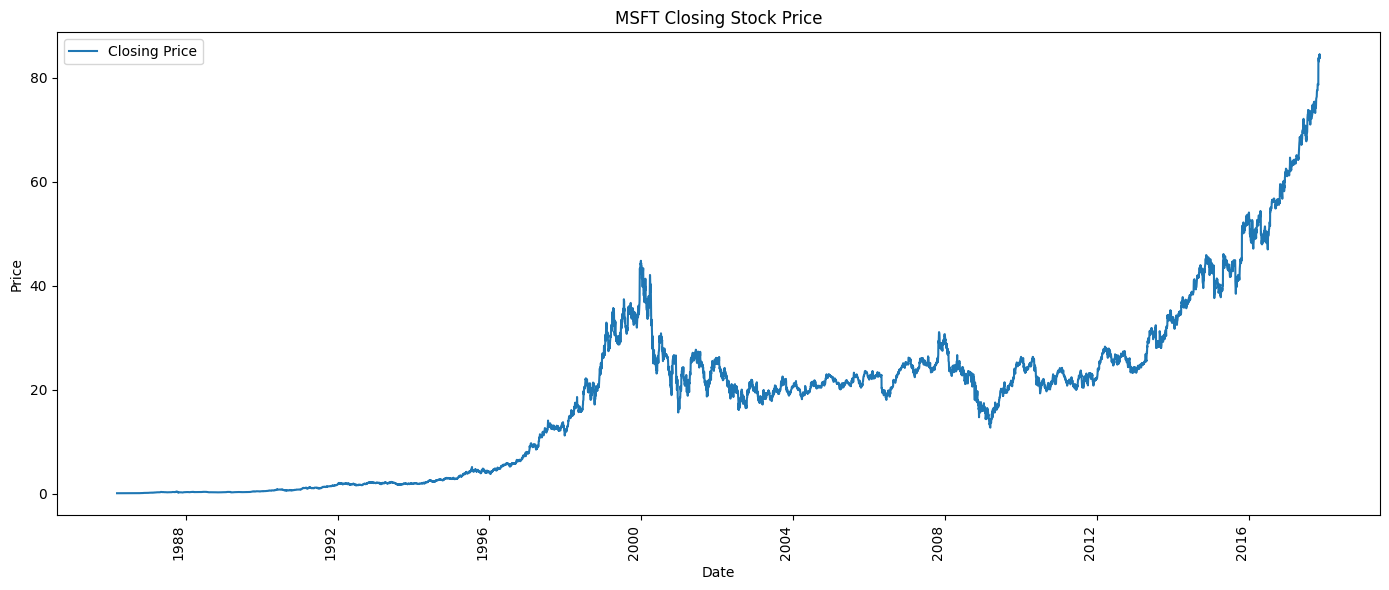

In [3]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(pd.to_datetime(df['Date']), df['Close'], label = "Closing Price")
plt.legend()
plt.title('MSFT Closing Stock Price')
plt.xlabel("Date")
plt.ylabel('Price')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [4]:
train, test = df.loc[df['Date'] <= '2003-12-31'], df.loc[df['Date'] > '2003-12-31']

In [5]:
train

,Date,Open,High,Low,Close
0,1986-03-13,0.06720,0.07533,0.06720,0.07533
1,1986-03-14,0.07533,0.07533,0.07533,0.07533
2,1986-03-17,0.07533,0.07533,0.07533,0.07533
3,1986-03-18,0.07533,0.07533,0.07533,0.07533
4,1986-03-19,0.07533,0.07533,0.07533,0.07533
...,...,...,...,...,...
4487,2003-12-24,20.41900,20.43700,20.31800,20.34400
4488,2003-12-26,20.35300,20.50300,20.31800,20.46900
4489,2003-12-29,20.46900,20.71400,20.43700,20.66300
4490,2003-12-30,20.62000,20.73200,20.61100,20.70500


In [6]:
scaler = StandardScaler()
scaler = scaler.fit(train[['Close']])
X_train = scaler.transform(train[['Close']])
X_test = scaler.transform(test[['Close']])

In [7]:
train[['Close']].shape

(4492, 1)

In [8]:
# As required for LSTM networks, we require to reshape an input data into (n_samples, timesteps, n_features). 
seq_size = 30  # Number of time steps to look back 
def to_sequences(x, y, seq_size=1):
    x_values = []
    y_values = []

    for i in range(len(x)-seq_size):
        #print(i)
        x_values.append(x[i:(i+seq_size)])
        y_values.append(y[i+seq_size])
        
    return np.array(x_values), np.array(y_values)

trainX, trainY = to_sequences(X_train, X_train, seq_size)
testX, testY = to_sequences(X_test, X_test, seq_size)


In [9]:
model = Sequential()
model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(rate=0.2))

model.add(RepeatVector(trainX.shape[1]))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(trainX.shape[2])))
model.compile(optimizer='adam', loss='mae')
model.summary()

c:\Users\Tina\TimeSeriesAnomalyDetection\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# fit model
history = model.fit(trainX, trainY, epochs=20, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1262 - val_loss: 0.0582
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0704 - val_loss: 0.0473
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0635 - val_loss: 0.0808
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0589 - val_loss: 0.0424
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0570 - val_loss: 0.0887
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0542 - val_loss: 0.0362
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0542 - val_loss: 0.0375
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0514 - val_loss: 0.0639
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0509 - val_loss: 0.0550
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0519 - val_loss: 0.0339
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0508 - val_loss: 0.0323
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 

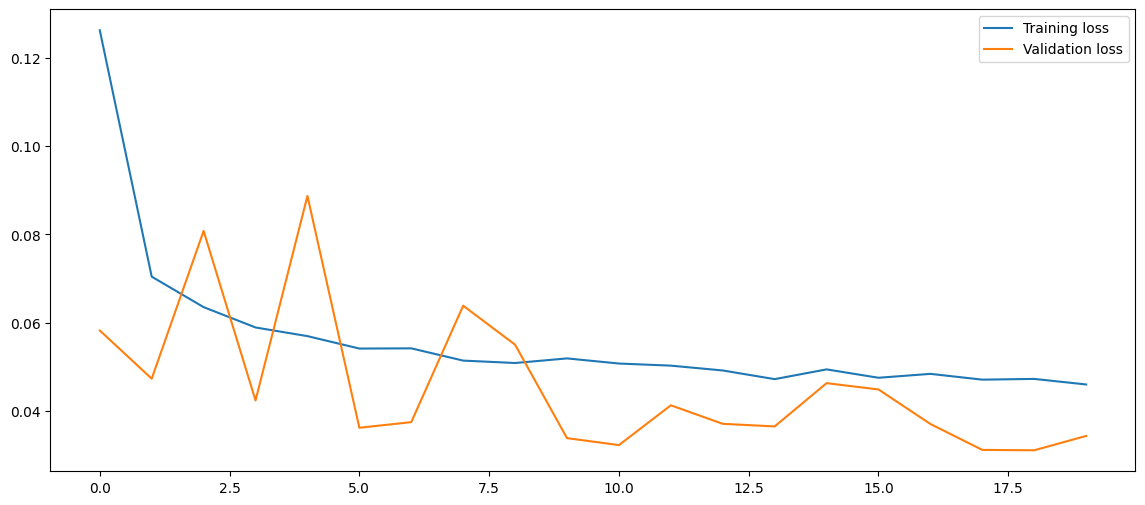

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


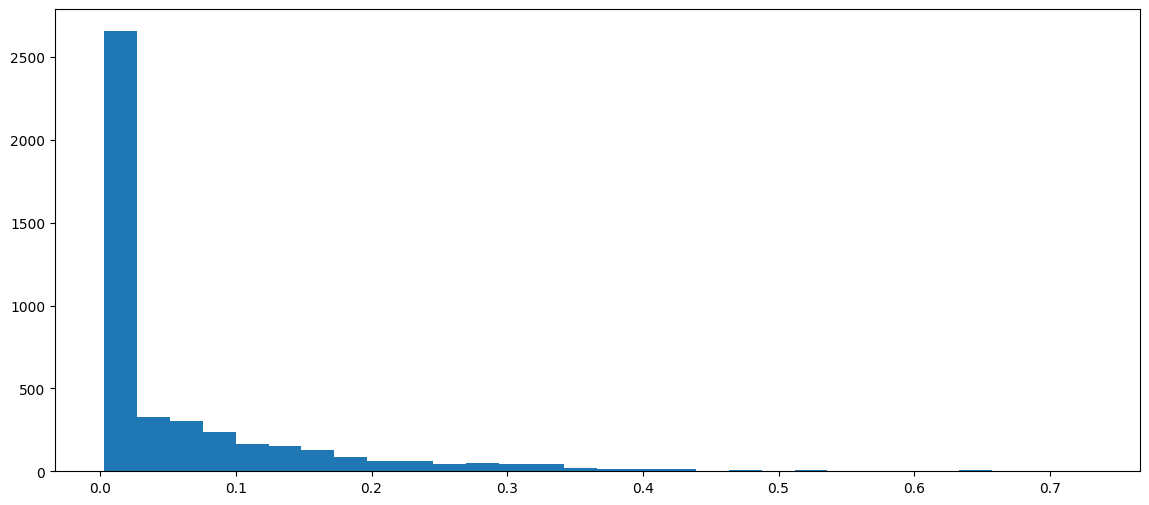

In [12]:
trainPredict = model.predict(trainX)
trainMAE = np.mean(np.abs(trainPredict - trainX), axis=1)
max_trainMAE = 0.3  #or Define 90% value of max as threshold.
fig, ax = plt.subplots(figsize=(14, 6))
plt.hist(trainMAE, bins=30)
plt.show()

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


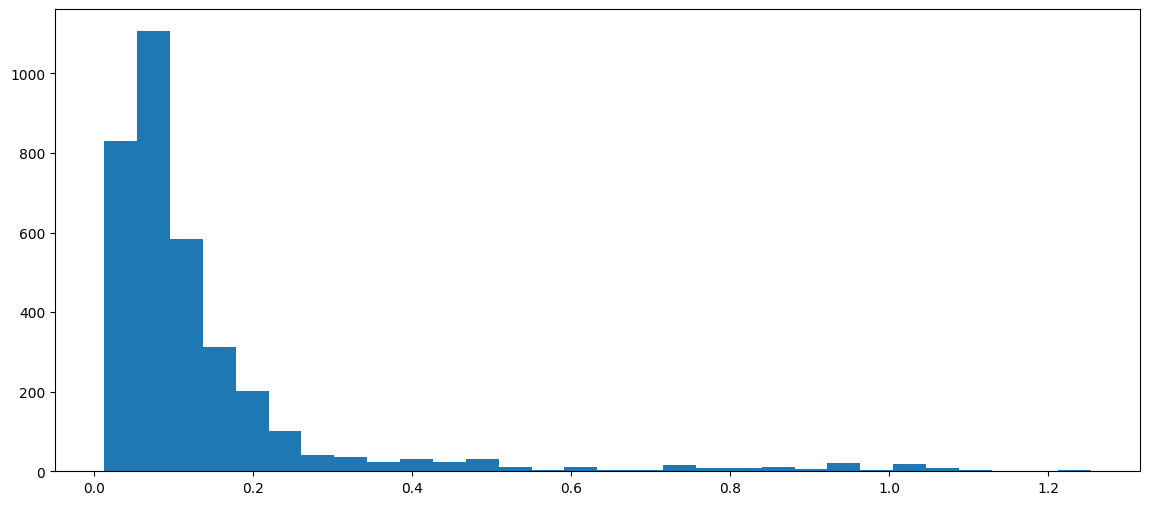

In [13]:
testPredict = model.predict(testX)
testMAE = np.mean(np.abs(testPredict - testX), axis=1)
fig, ax = plt.subplots(figsize=(14, 6))
plt.hist(testMAE, bins=30)
plt.show()

In [14]:
#Capture all details in a DataFrame for easy plotting
anomaly_df = pd.DataFrame(test[seq_size:])
anomaly_df['testMAE'] = testMAE
anomaly_df['max_trainMAE'] = max_trainMAE
anomaly_df['anomaly'] = anomaly_df['testMAE'] > anomaly_df['max_trainMAE']
anomaly_df['Close'] = test[seq_size:]['Close']

In [15]:
anomaly_df

,Date,Open,High,Low,Close,testMAE,max_trainMAE,anomaly
4522,2004-02-17,20.093,20.386,20.0090,20.310,0.047721,0.3,False
4523,2004-02-18,20.251,20.393,20.1180,20.144,0.041533,0.3,False
4524,2004-02-19,20.243,20.302,19.8820,19.909,0.042025,0.3,False
4525,2004-02-20,20.050,20.167,19.9410,19.990,0.051066,0.3,False
4526,2004-02-23,20.126,20.134,19.9260,20.024,0.050191,0.3,False
...,...,...,...,...,...,...,...,...
7978,2017-11-06,84.200,84.700,84.0825,84.470,1.127722,0.3,True
7979,2017-11-07,84.770,84.900,83.9300,84.260,1.154005,0.3,True
7980,2017-11-08,84.140,84.610,83.8300,84.560,1.189074,0.3,True
7981,2017-11-09,84.110,84.270,82.9000,84.090,1.214937,0.3,True


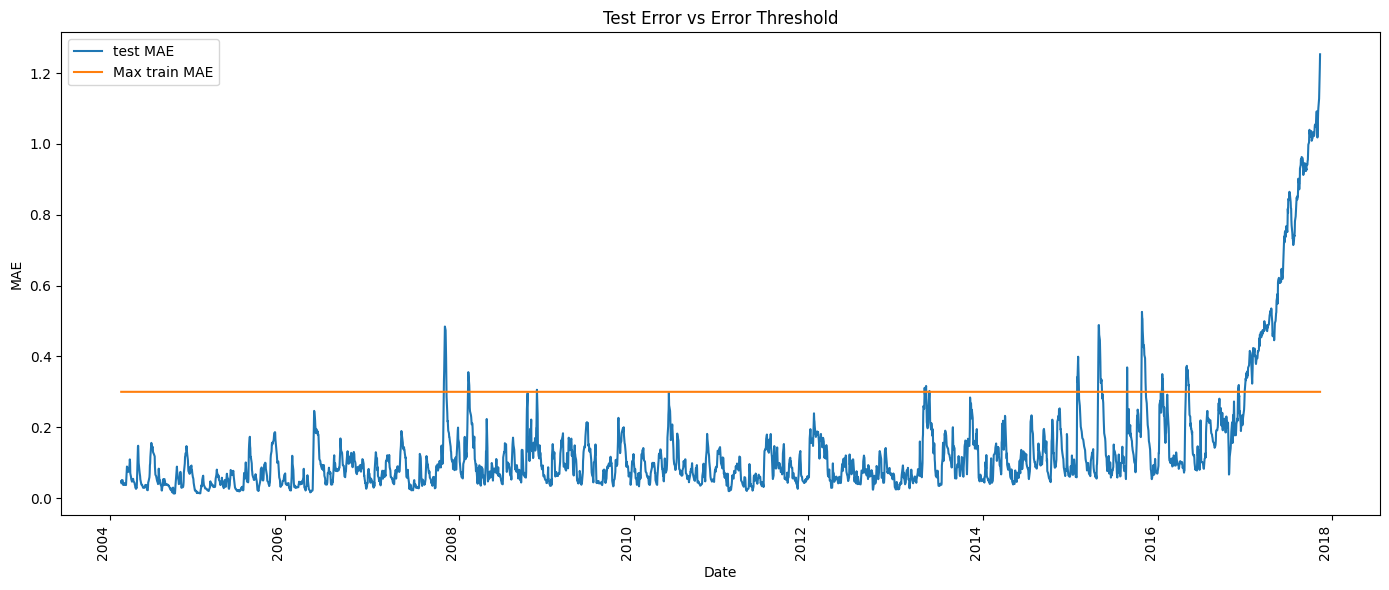

In [16]:
#Plot testMAE vs max_trainMAE
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(x=pd.to_datetime(anomaly_df['Date']), y=anomaly_df['testMAE'], label = "test MAE")
sns.lineplot(x=pd.to_datetime(anomaly_df['Date']), y=anomaly_df['max_trainMAE'], label = "Max train MAE")
plt.legend()
plt.title('Test Error vs Error Threshold')
plt.xlabel("Date")
plt.ylabel('MAE')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [17]:
anomalies = anomaly_df.loc[anomaly_df['anomaly'] == True]
test = scaler.inverse_transform(pd.DataFrame(anomaly_df['Close'])).reshape(len(anomaly_df), )
test2 = scaler.inverse_transform(pd.DataFrame(anomalies['Close'])).reshape(len(anomalies), ) 

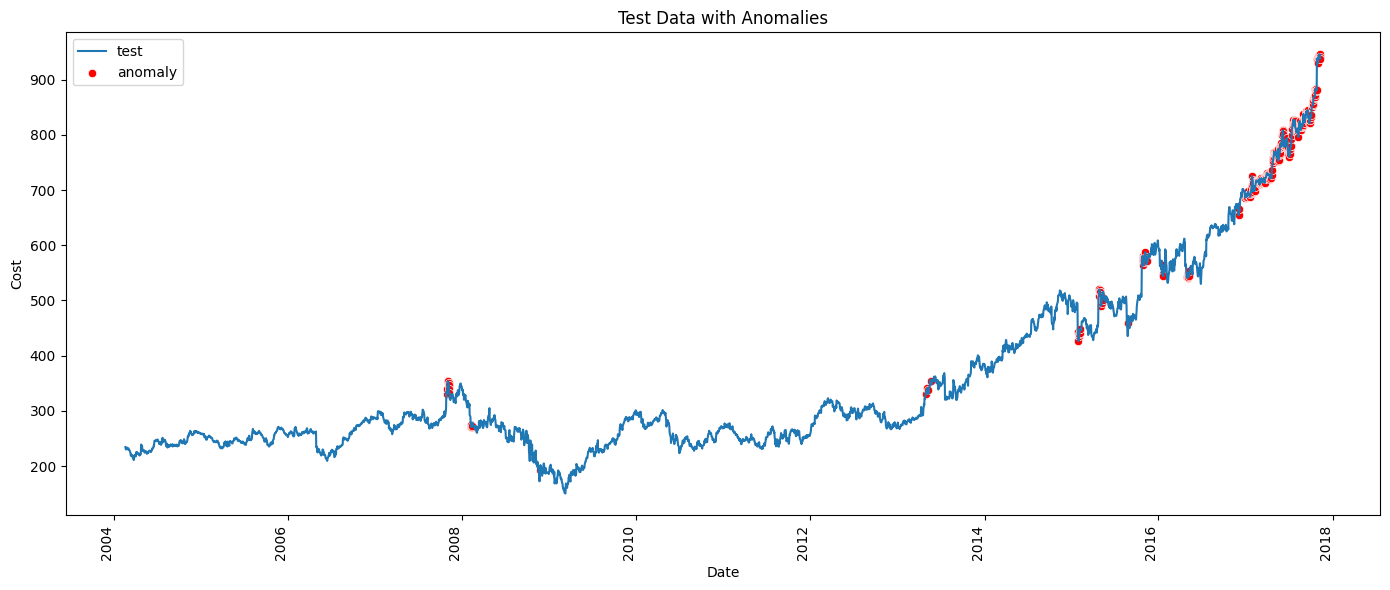

In [18]:
#Plot anomalies
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(x=pd.to_datetime(anomaly_df['Date']), y=test, label = "test")
sns.scatterplot(x=pd.to_datetime(anomalies['Date']), y=test2, color='r', label = "anomaly")
plt.legend()
plt.title('Test Data with Anomalies')
plt.xlabel("Date")
plt.ylabel('Cost')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()